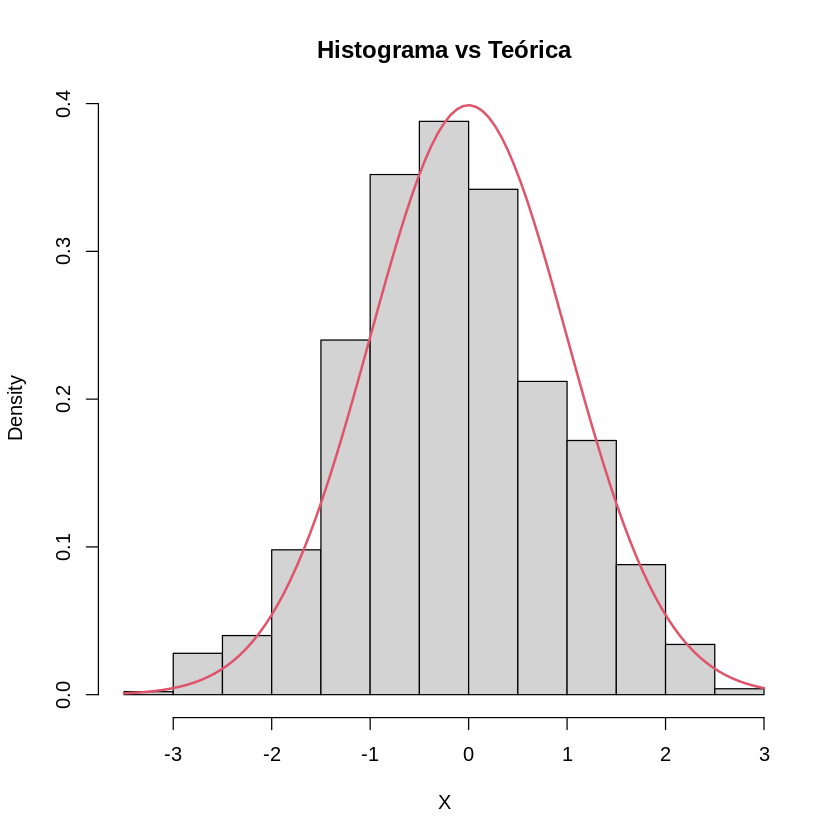

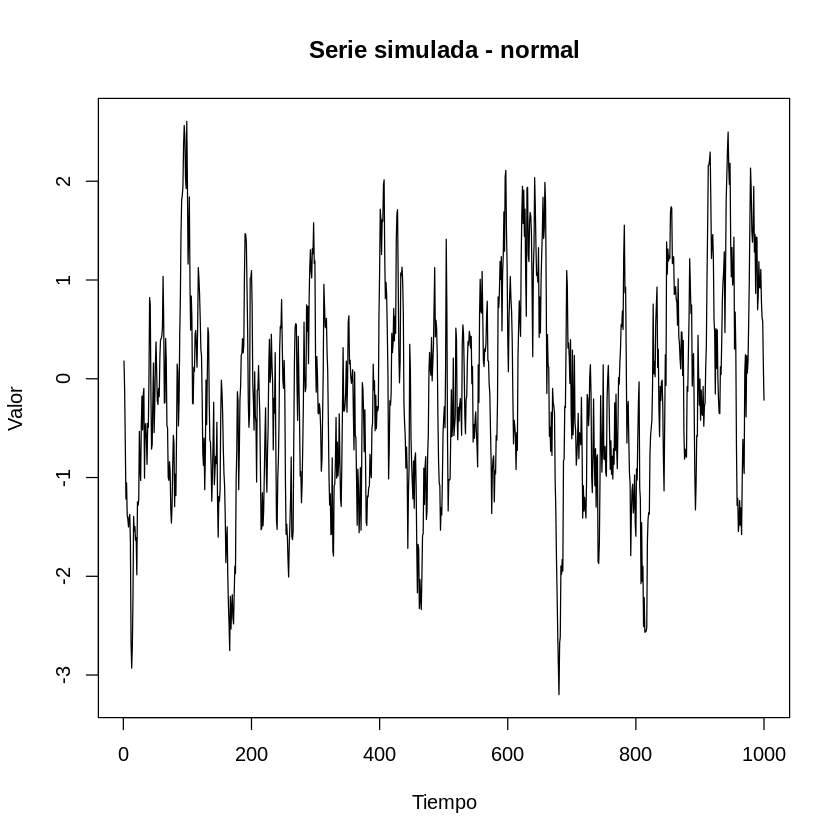

Warning message in bw.ucv(X):
“minimum occurred at one end of the range”


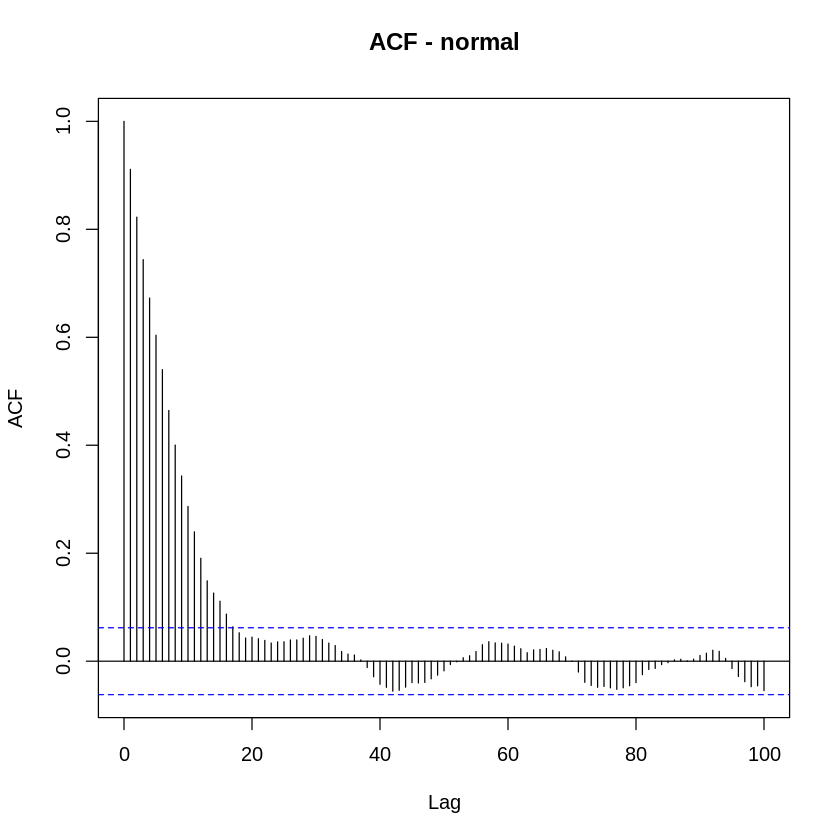

     Metodo         ISE
1        GL 0.011604788
2        CV 0.007678475
3 Silverman 0.007817372


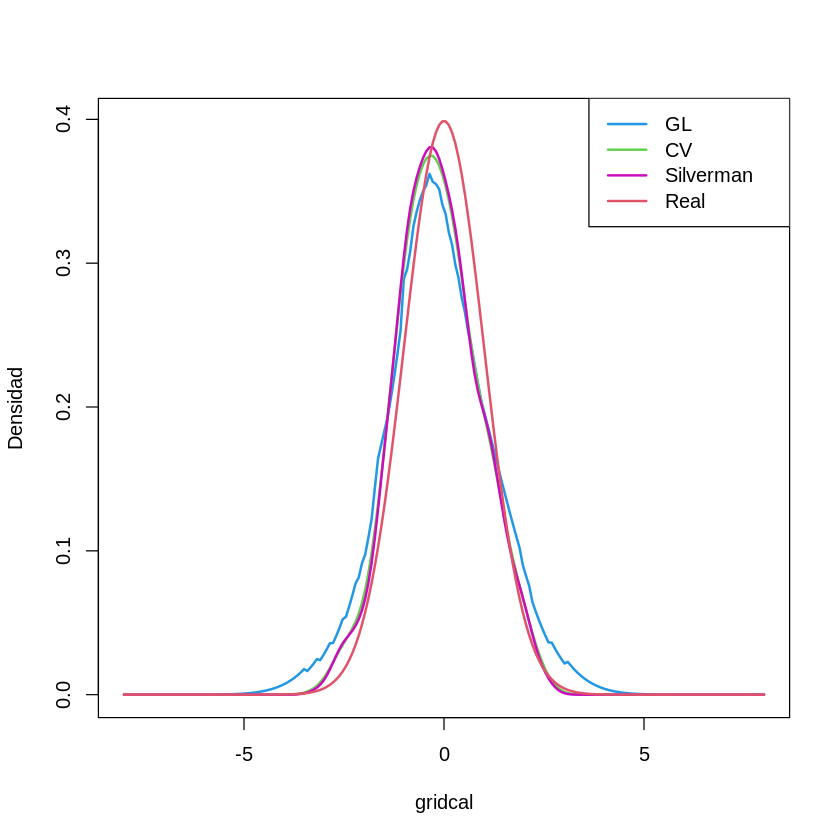

In [2]:
###########################################################
#                  Configuración de Parámetros
###########################################################
n <- 1000          # Tamaño de la muestra a simular
phi <- 0.9         # Coeficiente de autocorrelación (dependencia temporal)
densidad <- "normal" # Tipo de densidad objetivo ('normal', 'lognormal' o 'mezcla')
gamma <- 0.190000999 # Parámetro de penalización para el método GL

###########################################################
#### Parte 0: Funciones para la Densidad Mezcla
###########################################################

# Función de distribución acumulada (CDF) de la mezcla de dos normales
GMix <- function(x)
{
  return(0.5*pnorm(x, mean=-2, sd=1) + 0.5*pnorm(x, mean=2, sd=1))
}

# Creación de una malla de puntos y sus probabilidades para invertir la CDF
grid.mix.x <- seq(-8, 8, length.out=10000)
grid.mix.u <- GMix(grid.mix.x)

# Función cuantil (inversa de la CDF) aproximada mediante interpolación
QMix <- function(u)
{
  approx(x = grid.mix.u, y = grid.mix.x, xout = u, rule = 2)$y
}

###########################################################
#### Parte 1: Generación de Uniformes con Dependencia
###########################################################

# Simulación de un proceso autorregresivo AR(1) para introducir dependencia
Z <- arima.sim(model=list(ar=phi), n=n)

# Cálculo de la desviación estándar teórica del proceso estacionario
sd.Z <- sqrt(1/(1 - phi^2))

# Transformación Integral de Probabilidad para obtener U(0,1) con dependencia
U <- pnorm(Z, mean=0, sd=sd.Z)

###########################################################
#### Parte 2: Generación de la Muestra Objetivo
###########################################################

# Función para transformar las uniformes a la distribución deseada
GenerarMuestra <- function(U, densidad)
{
  if(densidad=="normal")
  {
    MP <- 1
    X <- qnorm(U)
    gsup <- 1/sqrt(2*pi) # Cota superior de la densidad (f_max)
    gridcal <- seq(-8, 8, length=200) # Malla para evaluar la estimación
    Delta <- diff(gridcal)[1]
  }
  else if(densidad=="lognormal")
  {
    MP <- 2
    X <- qlnorm(U, meanlog=0, sdlog=0.5)
    gsup <- exp(0.125)/(0.5*sqrt(2*pi))
    gridcal <- seq(0, qlnorm(0.999999, 0, 0.5), length=200)
    Delta <- diff(gridcal)[1]
  }
  else if(densidad=="mezcla")
  {
    MP <- 3
    X <- QMix(U)
    gsup <- 0.5*dnorm(-2, -2, 1) + 0.5*dnorm(-2, 2, 1)
    gridcal <- seq(-8, 8, length=200)
    Delta <- diff(gridcal)[1]
  }
  else
  {
    stop("Densidad no implementada")
  }

  return(list(X=X, gsup=gsup, MP=MP, gridcal=gridcal, Delta=Delta))
}

# Ejecución de la generación
Muestra <- GenerarMuestra(U, densidad)
X <- Muestra$X
gsup <- Muestra$gsup
MP <- Muestra$MP
gridcal <- Muestra$gridcal
Delta <- Muestra$Delta

###########################################################
#### Parte 3: Análisis Descriptivo y Visualización
###########################################################

# Visualización del histograma comparado con la densidad teórica
hist(X, probability = TRUE, breaks = 20, main="Histograma vs Teórica")

if(densidad=="normal") {curve(dnorm(x), add = TRUE, col = 2, lwd = 2)}
if(densidad=="lognormal") {curve(dlnorm(x, meanlog=0, sdlog=0.5), add=TRUE, col=2, lwd=2)}
if(densidad=="mezcla") {curve(0.5*dnorm(x, -2, 1) + 0.5*dnorm(x, 2, 1), add=TRUE, col=2, lwd=2)}

# Gráfico de la serie de tiempo y la función de autocorrelación (ACF)
plot(X, type="l", main=paste("Serie simulada -", densidad), xlab="Tiempo", ylab="Valor")
acf(X, lag.max = 100, main=paste("ACF -", densidad))

###########################################################
#### Parte 4: Estimación de Densidad GL (Goldenshluger-Lepski)
###########################################################

# Definición de la familia de ventanas candidatas (H)
u <- seq(0, floor(log(n))*(2/3), by = 0.1)
H <- exp(-u)

# Estimador de Núcleo (Kernel) Gaussiano básico
gh <- function(x, h, X)
{
  n <- length(X)
  return(sum(dnorm((x-X)/h))/(n*h))
}

# Estimador 'Sobresuavizado' para comparar dos ventanas h y hp
ghh <- function(x, h, hp, X)
{
  hs <- sqrt(h^2 + hp^2)
  return(gh(x, hs, X))
}

# Función de Penalización V(h) basada en la complejidad de la ventana
Vh <- function(h, n, gsup, gamma)
{
  delta.n <- sqrt(log(n))
  K1 <- 1
  K2 <- sqrt(1/(2*sqrt(pi)))

  return(
    sqrt(2*gamma*gsup)*K2*(K1+1)*(1+delta.n)*(((log(n))^(-1/2))/sqrt(n*h))
  )
}

# Criterio A(h,x): mide el error de aproximación local
Ahx <- function(x, h, H, X, n, gsup, gamma)
{
  valores <- numeric(length(H))
  for(i in seq_along(H))
  {
    hp <- H[i]
    # Compara el estimador h con otros hp más suaves
    valores[i] <- max(abs(ghh(x, h, hp, X) - gh(x, hp, X)) - Vh(hp, n, gsup, gamma), 0)
  }
  return(max(valores))
}

# Selección automática de la mejor ventana h para un punto x
hx <- function(x, H, X, n, gsup, gamma)
{
  criterio <- numeric(length(H))
  for(i in seq_along(H))
  {
    h <- H[i]
    criterio[i] <- Ahx(x, h, H, X, n, gsup, gamma) + Vh(h, n, gsup, gamma)
  }
  hhat <- H[which.min(criterio)]
  return(list(hhat=hhat, indice=which.min(criterio),
              criterio=criterio, ghat=gh(x, hhat, X)))
}

# Función principal para estimar la densidad en toda la malla
GLdens <- function(gridcal, H, X, n, gsup, gamma)
{
  m <- length(gridcal)
  ghat <- numeric(m)
  hhat <- numeric(m)

  for(i in 1:m)
  {
    res <- hx(gridcal[i], H, X, n, gsup, gamma)
    hhat[i] <- res$hhat
    ghat[i] <- res$ghat
  }
  return(list(ghat = ghat, hhat = hhat))
}

# Ejecutar estimación GL
GLgamma <- GLdens(gridcal, H, X, n, gsup, gamma)

###########################################################
#### Parte 5: Comparativa con Métodos Clásicos
###########################################################

# 1. Cross-Validation (Validación Cruzada)
hcv <- bw.ucv(X)
gh.cv <- sapply(gridcal, function(z) gh(z, hcv, X))

# 2. Regla de Silverman
h.sil <- bw.nrd0(X)
gh.sil <- sapply(gridcal, function(z) gh(z, h.sil, X))

# Determinar la densidad real para el cálculo del error (ISE)
if(MP==1) {g.real <- dnorm(gridcal)}
if(MP==2) {g.real <- dlnorm(gridcal, meanlog=0, sdlog=0.5)}
if(MP==3) {g.real <- 0.5*dnorm(gridcal, -2, 1) + 0.5*dnorm(gridcal, 2, 1)}

###########################################################
#### Parte 6: Resultados y Errores (ISE)
###########################################################

# Gráfico comparativo de todas las estimaciones
plot(gridcal, GLgamma$ghat, type="l", lwd=2, col=4,
     ylim=c(0, max(GLgamma$ghat, gh.cv, gh.sil, g.real)), ylab="Densidad")
lines(gridcal, gh.cv, col=3, lwd=2)
lines(gridcal, gh.sil, col=6, lwd=2)
lines(gridcal, g.real, col=2, lwd=2)
legend("topright", legend=c("GL", "CV", "Silverman", "Real"), col=c(4, 3, 6, 2), lwd=2)

# Cálculo del Error Cuadrático Integrado Aproximado (ISE)
ISE.GL  <- sum((GLgamma$ghat - g.real)^2) * Delta
ISE.CV  <- sum((gh.cv - g.real)^2) * Delta
ISE.SIL <- sum((gh.sil - g.real)^2) * Delta

print(data.frame(Metodo=c("GL", "CV", "Silverman"), ISE=c(ISE.GL, ISE.CV, ISE.SIL)))

### Comparativa de Rendimiento según el parámetro Gamma
En esta sección, evaluaremos cómo influye el parámetro de penalización $\gamma$ en la precisión de la estimación (ISE) para encontrar un valor óptimo.

        Gamma         ISE
1  0.01000000 0.012025757
2  0.06444444 0.008572519
3  0.11888889 0.009977955
4  0.17333333 0.011177062
5  0.22777778 0.012485303
6  0.28222222 0.013526028
7  0.33666667 0.014433648
8  0.39111111 0.015378640
9  0.44555556 0.016081411
10 0.50000000 0.016765297


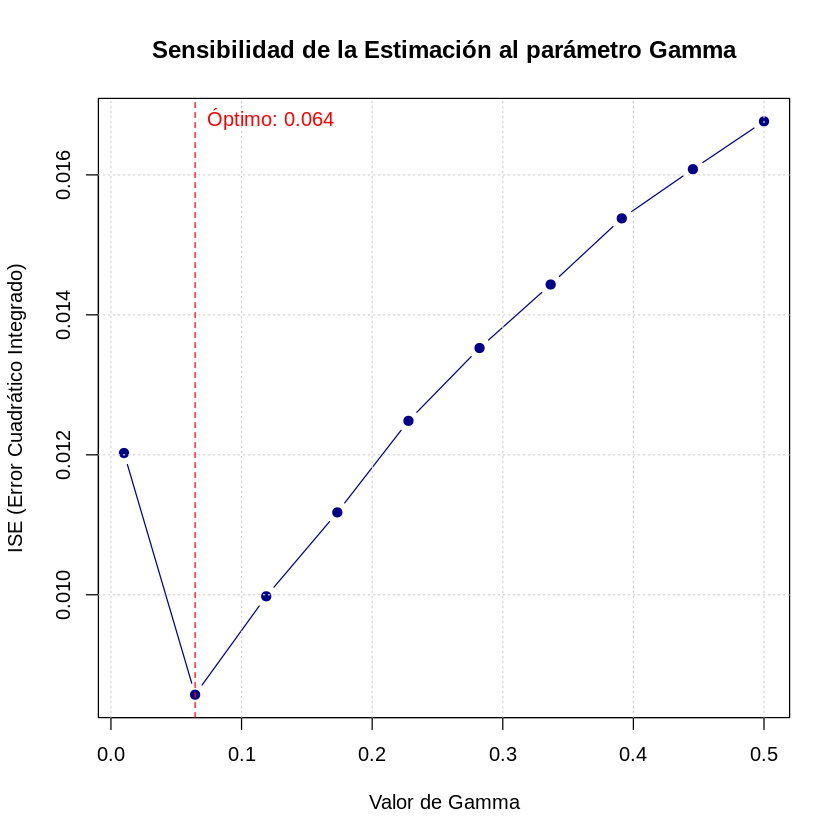

In [3]:
###########################################################
#### Parte 7: Sensibilidad del Estimador al parámetro Gamma
###########################################################

# Nota: Asegúrese de haber ejecutado la celda anterior con la definición de GLdens

# Definir un rango más fino de valores para gamma a probar
gamma_values <- seq(0.01, 0.6, length.out = 15)
ise_results <- numeric(length(gamma_values))

# Bucle para evaluar cada gamma y comparar el error (ISE)
message("Iniciando simulación de sensibilidad para gamma...")
for(i in seq_along(gamma_values)) {
  current_gamma <- gamma_values[i]

  # Ejecutar la estimación GL con el gamma actual
  # Esta función debe estar definida en la celda anterior
  res_temp <- GLdens(gridcal, H, X, n, gsup, current_gamma)

  # Calcular el ISE (Integral Squared Error)
  ise_results[i] <- sum((res_temp$ghat - g.real)^2) * Delta
}

# Crear un dataframe con los resultados para análisis numérico
performance_df <- data.frame(Gamma = gamma_values, ISE = ise_results)
print(performance_df)

# Visualización de la curva de error para identificar el codo o mínimo
plot(performance_df$Gamma, performance_df$ISE, type="b",
     pch=19, col="darkblue", lwd=2,
     xlab="Parámetro de Penalización (Gamma)",
     ylab="ISE (Error Cuadrático Integrado)",
     main="Optimización del Parámetro Gamma en GL")
grid()

# Identificar y resaltar el mejor gamma (mínimo error)
best_idx <- which.min(performance_df$ISE)
best_gamma <- performance_df$Gamma[best_idx]
best_ise <- performance_df$ISE[best_idx]

abline(v = best_gamma, col="red", lty=2, lwd=2)
points(best_gamma, best_ise, col="red", cex=2, lwd=2)
text(best_gamma, max(performance_df$ISE),
     labels=paste("Gamma óptimo =", round(best_gamma, 3)),
     pos=4, col="red", font=2)